Title: SEM_application_ERA5.ipynb

Purpose: 

Author: Onno Nennecke on 19.03.2025 Modified: 03.05.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import glob
import re

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Define variables (all in the config file)


```python
Wind:
- alpha_on = 1/7    # Roughness parameter onshore  
- alpha_off = 0.11  # Roughness parameter offshore  
- ref_height = 10   # Height of wind data  
- v_cutin = 3.5     # Minimum wind speed to start producing power  
- v_cutout = 25     # Maximum wind speed to produce power  
- v_rated = 13      # Wind speed at which the turbine produces maximum power  
- time_oper = 24    # operational time of hub [h/day]  
- Hub Height:
    - # hub_height_on = 80    # Approximation: Onshore 80 m --> Bad Approximation --> Used own grid data instead  
    - # hub_height_off = 120  # Approximation: Offshore 120 m --> Bad Approximation --> Used own grid data instead  

Solar:

- cT_c1 = 4.3       # constant [dC]  
- cT_c2 = 0.943     # constant [-]  
- cT_c3 = 0.028     # constant [dC m2 W-1]  
- cT_c4 = -1.528    # constant [dC s m-1]  
- gamma = -0.005    # constant [--]  
- temp_ref = 25     # reference temperature [dC]  
- gstc = 1000       # standard test conditions [W m-2]  
- shift_doy = 186   # if HadGEM : 180  
```

### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [3]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [4]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

### Load ERA5 Data

In [5]:
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen


In [6]:
# Select all files

# base_path = '/climca/data/ERA5/daily'
# path = os.path.join(base_path, variable, '*')
# all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
# all_files = sorted(all_files)
# all_files
# nc = xr.open_mfdataset(all_files)
# nc

In [7]:
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files


In [8]:
# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

{'SSRD': <xarray.Dataset> Size: 25MB
 Dimensions:  (time: 3653, lat: 37, lon: 47)
 Coordinates:
   * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
   * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
   * time     (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
 Data variables:
     var169   (time, lat, lon) float32 25MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
 Attributes:
     CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
     Conventions:  CF-1.6
     institution:  European Centre for Medium-Range Weather Forecasts
     history:      Wed Apr 03 17:39:36 2024: cdo -f nc -remapnn,U100_2023.nc S...
     CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...,
 'U100': <xarray.Dataset> Size: 25MB
 Dimensions:  (time: 3653, lat: 37, lon: 47)
 Coordinates:
   * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
   * lon      (lon) fl

### Check data variables

In [9]:
# datasets_by_variable['SSRD'] # var169
# datasets_by_variable['U100'] # var246
# datasets_by_variable['V100'] # var247
datasets_by_variable['tas']  # var167
# datasets_by_variable['tasmax']

<xarray.Dataset> Size: 25MB
Dimensions:  (time: 3653, lat: 37, lon: 47)
Coordinates:
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
  * time     (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    var167   (time, lat, lon) float32 25MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:37:15 2024: cdo -f nc -sellonlatbox,3,17,56,4...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [10]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

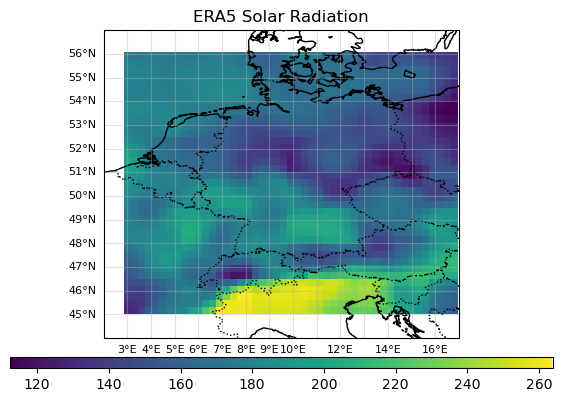

In [ ]:
SSRD_pl = datasets_by_variable['SSRD']

timestep = 90
lon_edges = SSRD_pl['lon'].values
lat_edges = SSRD_pl['lat'].values

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([5-3, 16+1, 47-3, 56+1], crs=ccrs.PlateCarree()) #[5, 16, 47, 56]
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.set_title('ERA5 Solar Radiation')

xxx1 = SSRD_pl['var169'].isel(time=timestep)
im1 = ax.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='viridis')
setup_gridlines(ax)
cbar1 = fig.colorbar(im1, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.show()

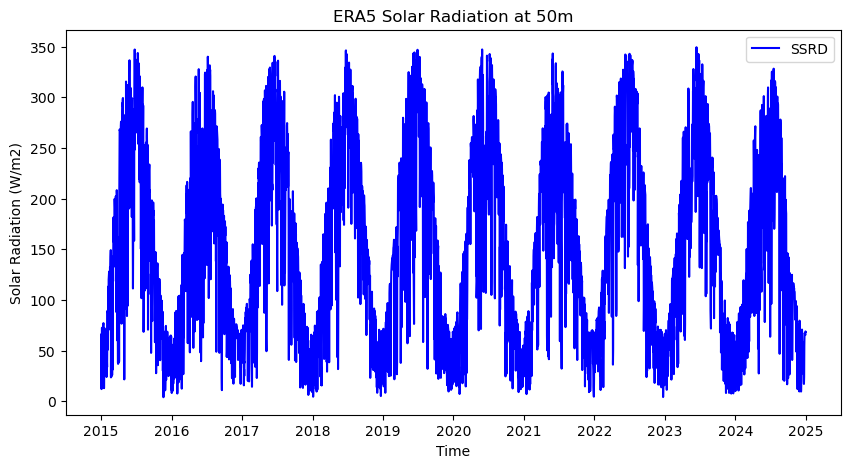

In [12]:
tst = SSRD_pl['var169']
# Plot timeseries of ssrd
fig, ax = plt.subplots(figsize=(10, 5))
tst.isel(lon=10, lat=5).plot(ax=ax, color='blue', label='SSRD')
ax.set_title('ERA5 Solar Radiation at 50m')
ax.set_xlabel('Time')
ax.set_ylabel('Solar Radiation (W/m2)')
ax.legend()
plt.show()

### Prepare data

- rename variables
- regrid data
- calculate windspeed
- convert K to °C
- remove 29.02

In [15]:
var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds) # One ° less in the north to prevent NaN values #, s = 47, n = 56, w = 6, e = 16
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

In [16]:
clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds.where(~((clim_ds['time.month'] == 2) & (clim_ds['time.day'] == 29)), drop=True)
combined_ds

<xarray.Dataset> Size: 8MB
Dimensions:     (time: 3650, lat: 9, lon: 10)
Coordinates:
  * time        (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat         (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs         int64 8B 4326
    gridtype    <U6 24B 'lonlat'
  * lon         (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds        (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    U100        (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    V100        (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    tas         (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    tasmax      (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    wind_speed  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Run model

In [17]:
wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['wind_speed'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['wind_speed'], grid_onsh_hub_height, config.a_onshore, config.height_ref)

combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['wind_speed'])

# combined_ds['solar_pot'] = sepot['solar_pot']
combined_ds['solar_pot'] = sepot

seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

# combined_ds['solar_prod'] = seprod['solar_prod']
combined_ds['solar_prod'] = seprod

In [18]:
# Calculate weighted sum

weighted_temp_list = []
for y in np.unique(combined_ds['tas']["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
ds_weighted_temp.load()

<xarray.Dataset> Size: 58kB
Dimensions:   (time: 3650)
Coordinates:
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
Data variables:
    temp      (time) float64 29kB 1.323 3.335 2.591 ... -0.6738 0.7396 0.4142

In [19]:
ds_weighted_temp_w = xr.concat(
    [
        ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] < 5, drop=True),
        ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] >= 5, drop=True),
    ],
    "period",
)

ds_weighted_temp_w["period"] = ["weekday", "weekend"]
ds_weighted_temp_w.load()

<xarray.Dataset> Size: 88kB
Dimensions:   (period: 2, time: 3650)
Coordinates:
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
  * period    (period) <U7 56B 'weekday' 'weekend'
Data variables:
    temp      (period, time) float64 58kB 1.323 3.335 nan ... -0.6738 nan nan

In [20]:
# Calculate demand

# Calculate demand during weekdays
demand_weekday = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekday'), demand_fit_values.sel(country = 9, period = 'weekday'))
# Calculate demand during weekends
demand_weekend = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekend'), demand_fit_values.sel(country = 9, period = 'weekend'))
# Combine both datasets
demand_ds = (demand_weekday).fillna(0) + (demand_weekend).fillna(0)

# Averaged demand (prob not used)
demand_week = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

In [21]:
timeseries_ds = demand_ds.copy()

timeseries_ds['sfcWind'] = combined_ds['wind_speed'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

# timeseries_ds['sfcWind'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5_wwd', ESM_run = 'ERA5_hist_wwd', period = 'week')
ts_output.load()
# ts_output.to_netcdf('/climca/people/onennecke/model_output/bias_corrected/full_year/ERA5_timeseries_wwd.nc')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_wwd.nc')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/bias_corrected_masked/full_year/ERA5_timeseries_wwd.nc')
ts_output.to_netcdf('/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/ERA5_timeseries_wwd.nc')

In [22]:
timeseries_ds = demand_week.copy()

timeseries_ds['sfcWind'] = combined_ds['wind_speed'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

# timeseries_ds['sfcWind'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5_week', ESM_run = 'ERA5_hist_week')
ts_output.load()
# ts_output.to_netcdf('/climca/people/onennecke/model_output/bias_corrected/full_year/ERA5_timeseries_week.nc')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_week.nc')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/bias_corrected_masked/full_year/ERA5_timeseries_week.nc')
ts_output.to_netcdf('/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/ERA5_timeseries_week.nc')

In [23]:
ts_output

<xarray.Dataset> Size: 321kB
Dimensions:        (time: 3650)
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U7 28B 'week'
    run            <U4 16B 'hist'
    ESM            <U9 36B 'ERA5_week'
    ESM_run        <U14 56B 'ERA5_hist_week'
Data variables:
    temp           (time) float64 29kB 1.323 3.335 2.591 ... 0.7396 0.4142
    demand         (time) float64 29kB 1.504e+03 1.479e+03 ... 1.515e+03
    sfcWind        (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds           (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas            (time) float32 15kB 1.771 3.587 3.046 ... 0.2238 1.512 1.194
    tasmax         (time) float32 15kB 3.431 5.871 4.704 ... 2.446 2.709 3.361
    wind_off_prod  (time) float64 29kB 221.2 0.1512 221.2 ... 221.1 221.2 221.2
    wind_on_prod   (time) float64 29kB 1.019e+03 1.475e+03 ... 1.187e+03
    solar_prod     (time) float64 29kB 91.22 46.73 45.84 ... 88.35 81.4 102.9
    total_prod     (time) float64 29kB 1.331e+03 1.522e+03 ... 1.511e+03
    Netto          (time) float64 29kB -172.6 42.99 -39.17 ... -118.3 -3.33
    Residual_load  (time) float64 29kB 172.6 -42.99 39.17 ... 649.7 118.3 3.33

In [20]:
ts_output

<xarray.Dataset> Size: 321kB
Dimensions:        (time: 3650)
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U7 28B 'week'
    run            <U4 16B 'hist'
    ESM            <U9 36B 'ERA5_week'
    ESM_run        <U14 56B 'ERA5_hist_week'
Data variables:
    temp           (time) float64 29kB 1.323 3.335 2.591 ... 0.7396 0.4142
    demand         (time) float64 29kB 1.504e+03 1.479e+03 ... 1.515e+03
    sfcWind        (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds           (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas            (time) float32 15kB 1.771 3.587 3.046 ... 0.2238 1.512 1.194
    tasmax         (time) float32 15kB 3.431 5.871 4.704 ... 2.446 2.709 3.361
    wind_off_prod  (time) float64 29kB 221.2 0.1512 221.2 ... 221.1 221.2 221.2
    wind_on_prod   (time) float64 29kB 1.019e+03 1.475e+03 ... 1.187e+03
    solar_prod     (time) float64 29kB 91.22 46.73 45.84 ... 88.35 81.4 102.9
    total_prod     (time) float64 29kB 1.331e+03 1.522e+03 ... 1.511e+03
    Netto          (time) float64 29kB -172.6 42.99 -39.17 ... -118.3 -3.331
    Residual_load  (time) float64 29kB 172.6 -42.99 39.17 ... 649.7 118.3 3.331

In [22]:
ts_ERA5 = ts_output.drop_vars(['wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load', 'Netto', 'demand', 'temp', 'period', 'country'])
ts_ERA5
# ts_ERA5.to_netcdf(f'/climca/people/onennecke/model_output/var_means/ERA5_timeseries.nc')


<xarray.Dataset> Size: 88kB
Dimensions:   (time: 3653)
Coordinates:
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    run       <U4 16B 'hist'
    ESM       <U9 36B 'ERA5_week'
    ESM_run   <U14 56B 'ERA5_hist_week'
Data variables:
    sfcWind   (time) float32 15kB 7.507 11.86 9.267 8.975 ... 6.159 8.049 8.775
    rsds      (time) float32 15kB 30.54 19.51 17.85 35.4 ... 28.84 26.3 31.92
    tas       (time) float32 15kB 1.771 3.587 3.046 2.561 ... 0.2238 1.512 1.194
    tasmax    (time) float32 15kB 3.431 5.871 4.704 4.24 ... 2.446 2.709 3.361

### Some demand checking

In [21]:
# Calculate ratio from approximated demand with one fit value and the demand values with two fit values
a = demand_weekday['demand'].sum(skipna=True).values + demand_weekend['demand'].sum(skipna=True).values
b = demand_week['demand'].sum(skipna=True).values
c = demand_weekday['demand'][0:10].sum(skipna=True).values + demand_weekend['demand'][0:10].sum(skipna=True).values
d = demand_week['demand'][0:10].sum(skipna=True).values
print(a/b)
print(c/d)

0.999273207163723
0.9972660542208472


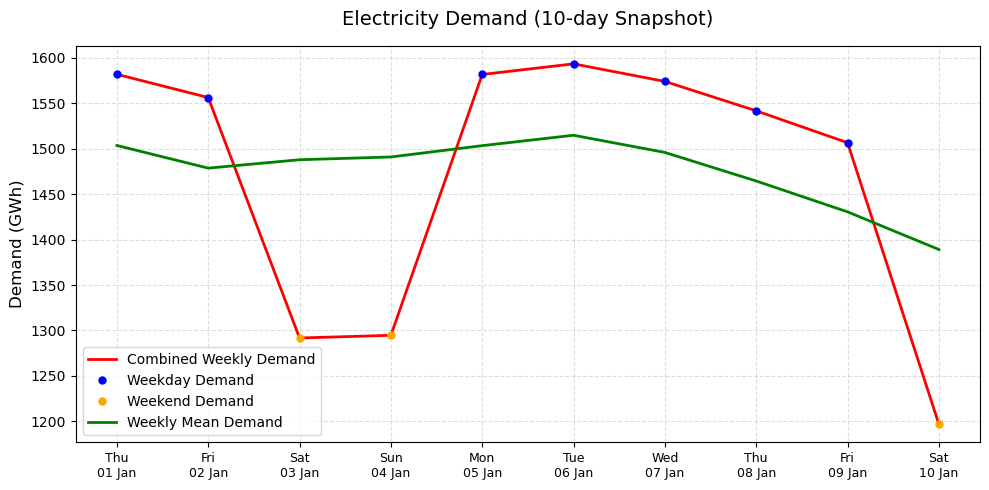

In [22]:
# Compare the different demand curves
fig, ax = plt.subplots(figsize=(10, 5))

demand_ds['demand'][0:10].plot(ax=ax, color='red', label='Combined Weekly Demand', linewidth=2)
demand_weekday['demand'][0:10].plot(ax=ax, color='blue', label='Weekday Demand', marker='o', linestyle='', markersize=5)
demand_weekend['demand'][0:10].plot(ax=ax, color='orange', label='Weekend Demand', marker='o', linestyle='', markersize=5)
demand_week['demand'][0:10].plot(ax=ax, color='green', label='Weekly Mean Demand', linewidth=2)

# Format x-axis as short weekday + date
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)

# Add grid for readability
ax.grid(True, linestyle='--', alpha=0.4)

# Title and labels
ax.set_title('Electricity Demand (10-day Snapshot)', fontsize=14, pad=15)
ax.set_ylabel('Demand (GWh)', fontsize=12)
ax.set_xlabel('')  # Remove label; already included in tick formatting

# Custom legend
ax.legend(frameon=True, fontsize=10, loc='lower left')

# Tight layout
plt.tight_layout()
plt.show()

#### Some plots to check everything is alright

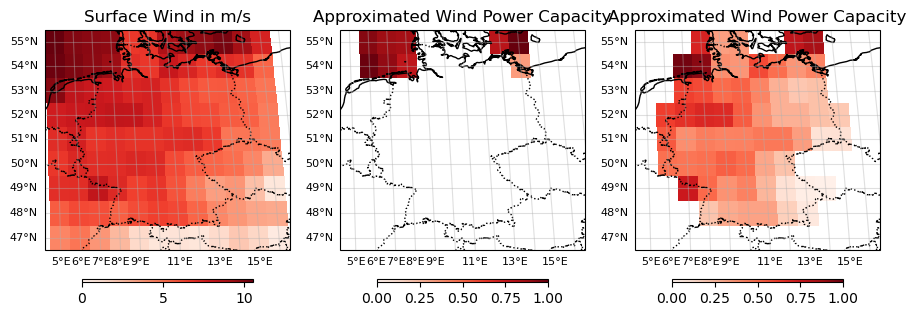

In [23]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 100

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['wind_speed'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax3)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()


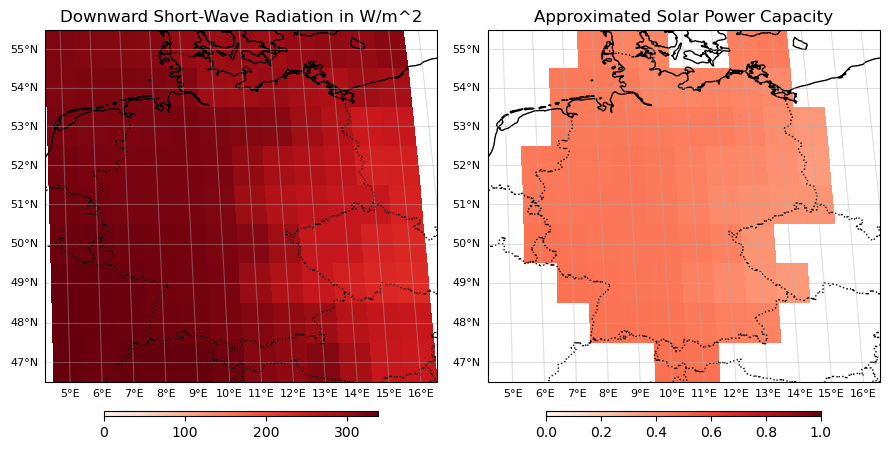

In [24]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 180 #29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

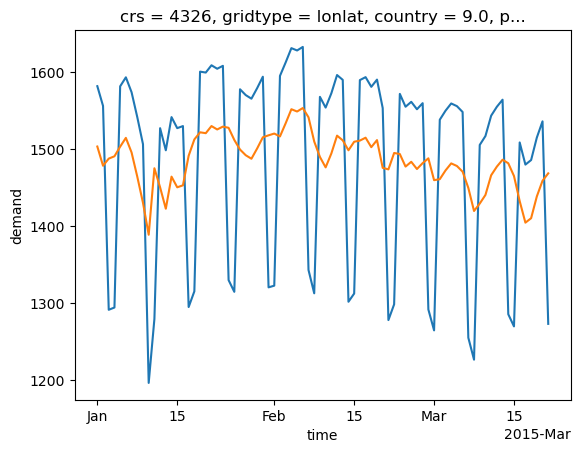

In [25]:
demand_ds['demand'][0:80].plot()
demand_week['demand'][0:80].plot()

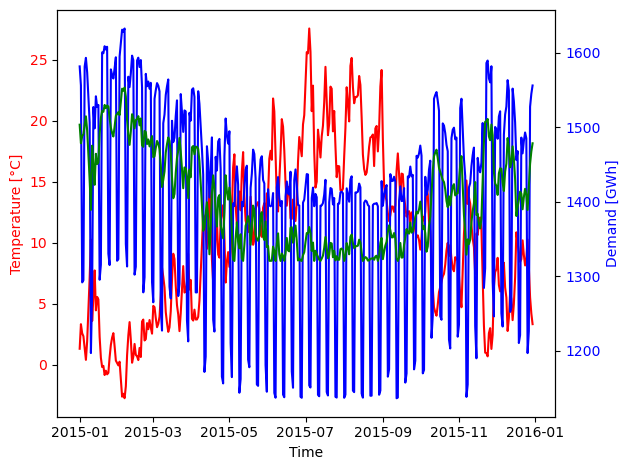

In [26]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.plot(demand_ds['time'][a:b], demand_week['demand'][a:b], label='Demand', color='g')

ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

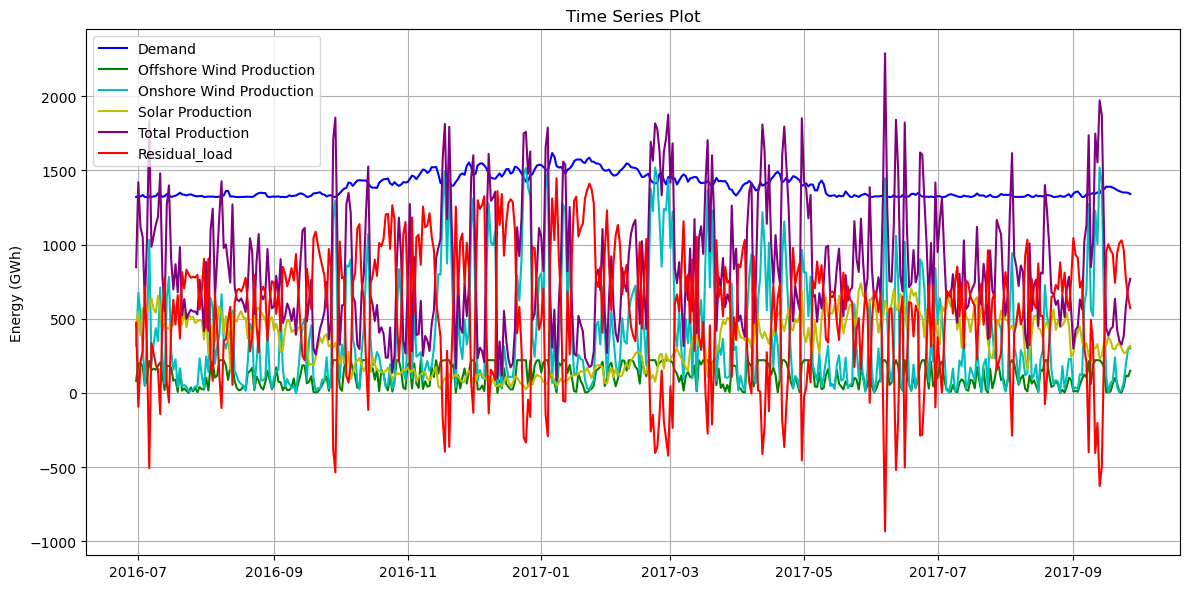

In [27]:

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
# a = 0
# b = 364
a = 365 * 3 + 6 * 30
b = 365 * 4 + 9 * 30
a = 365 * 1 + 6 * 30
b = 365 * 2 + 9 * 30

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()



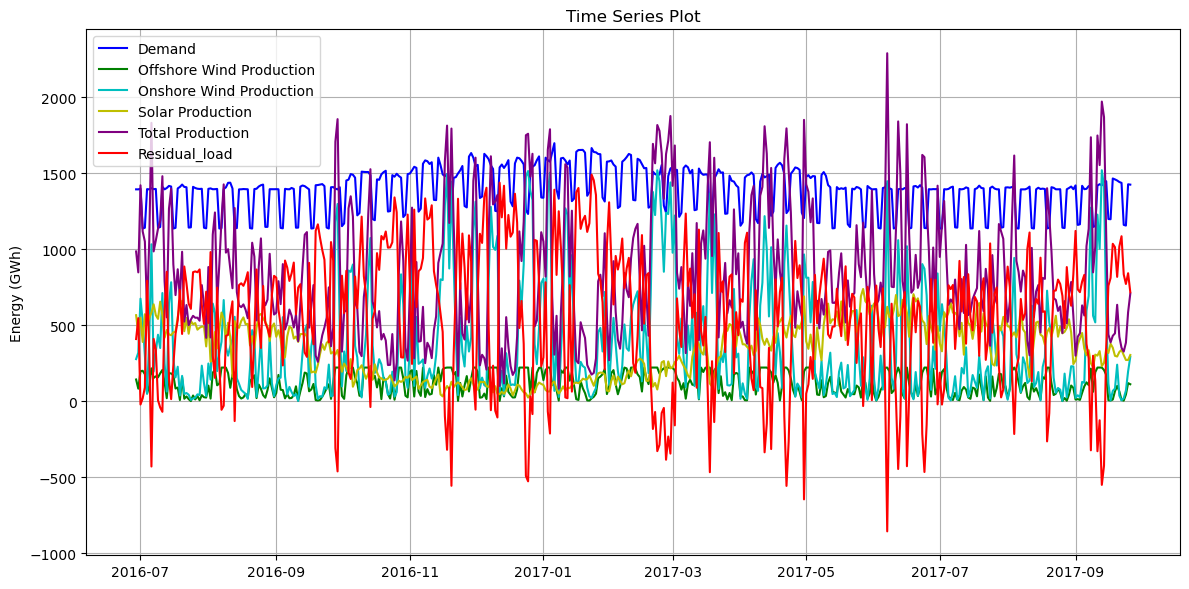

In [28]:
timeseries_ds = xr.open_dataset('/climca/people/onennecke/model_output/bias_corrected_masked/full_year/ERA5_timeseries_wwd.nc')
# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
# a = 0
# b = 364
a = 365 * 3 + 6 * 30
b = 365 * 4 + 9 * 30
a = 365 * 1 + 6 * 30
b = 365 * 2 + 9 * 30

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

